In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import cv2
import os

# --- CONFIGURATION ---
MODEL_PATH = "fusion_model.pth" 
IMG_SIZE = 256                  

# --- HARDWARE SETUP ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Generator hardware: {DEVICE}")

# --- 1. DEFINE THE ADVANCED MODEL ARCHITECTURE ---
class AdvancedFusionNet(nn.Module):
    def __init__(self):
        super(AdvancedFusionNet, self).__init__()
        
        # Encoder
        self.enc1 = nn.Sequential(nn.Conv2d(6, 32, 3, 1, 1), nn.BatchNorm2d(32), nn.ReLU(inplace=True))
        self.enc2 = nn.Sequential(nn.Conv2d(32, 64, 3, 2, 1), nn.BatchNorm2d(64), nn.ReLU(inplace=True))
        self.enc3 = nn.Sequential(nn.Conv2d(64, 128, 3, 2, 1), nn.BatchNorm2d(128), nn.ReLU(inplace=True))
        
        # Bottleneck
        self.bottle = nn.Sequential(nn.Conv2d(128, 128, 3, 1, 1), nn.BatchNorm2d(128), nn.ReLU(inplace=True))
        
        # Decoder + Skip Connections
        self.up3 = nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1)
        self.dec3 = nn.Sequential(nn.Conv2d(128, 64, 3, 1, 1), nn.BatchNorm2d(64), nn.ReLU(inplace=True))
        
        self.up2 = nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1)
        self.dec2 = nn.Sequential(nn.Conv2d(64, 32, 3, 1, 1), nn.BatchNorm2d(32), nn.ReLU(inplace=True))
        
        self.final = nn.Conv2d(32, 3, kernel_size=3, padding=1)
        
    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        
        b = self.bottle(e3)
        
        d3 = self.up3(b)
        d3 = torch.cat([d3, e2], dim=1) 
        d3 = self.dec3(d3)
        
        d2 = self.up2(d3)
        d2 = torch.cat([d2, e1], dim=1) 
        d2 = self.dec2(d2)
        
        return torch.sigmoid(self.final(d2))

# --- 2. LOAD THE TRAINED MODEL ---
model = AdvancedFusionNet().to(DEVICE)
if os.path.exists(MODEL_PATH):
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    model.eval() 
    print("✅ Advanced AI Brain Loaded Successfully!")
else:
    print(f"❌ Error: {MODEL_PATH} not found. Train the model first.")

# --- 3. UPGRADED WARPING LOGIC ---
def warp_tensor(img_tensor, flow_tensor):
    N, C, H, W = img_tensor.shape
    xx = torch.arange(0, W).view(1, -1).repeat(H, 1)
    yy = torch.arange(0, H).view(-1, 1).repeat(1, W)
    xx = xx.view(1, 1, H, W).repeat(N, 1, 1, 1)
    yy = yy.view(1, 1, H, W).repeat(N, 1, 1, 1)
    grid = torch.cat((xx, yy), 1).float()
    if img_tensor.device.type != 'cpu': 
        grid = grid.to(DEVICE)
    vgrid = grid + flow_tensor
    vgrid[:, 0, :, :] = 2.0 * vgrid[:, 0, :, :] / max(W - 1, 1) - 1.0
    vgrid[:, 1, :, :] = 2.0 * vgrid[:, 1, :, :] / max(H - 1, 1) - 1.0
    vgrid = vgrid.permute(0, 2, 3, 1)
    
    # padding_mode='border' prevents pure black tearing
    return F.grid_sample(img_tensor, vgrid, align_corners=True, padding_mode='border')

def interpolate_two_images(img1_s, img2_s):
    """Core function: Generates exactly ONE 50% intermediate frame."""
    prev_gray = cv2.cvtColor(img1_s, cv2.COLOR_BGR2GRAY)
    next_gray = cv2.cvtColor(img2_s, cv2.COLOR_BGR2GRAY)
    
    flow = cv2.calcOpticalFlowFarneback(prev_gray, next_gray, None, 0.5, 5, 25, 10, 5, 1.2, 0)
    
    t1 = torch.from_numpy(img1_s).permute(2, 0, 1).float().unsqueeze(0) / 255.0
    t2 = torch.from_numpy(img2_s).permute(2, 0, 1).float().unsqueeze(0) / 255.0
    t_flow = torch.from_numpy(flow).permute(2, 0, 1).float().unsqueeze(0)
    
    t1, t2, t_flow = t1.to(DEVICE), t2.to(DEVICE), t_flow.to(DEVICE)
    
    with torch.no_grad():
        warped_1 = warp_tensor(t1, t_flow * 0.5)
        warped_2 = warp_tensor(t2, t_flow * -0.5)
        cnn_input = torch.cat([warped_1, warped_2], dim=1)
        output = model(cnn_input)
        
    out_img = output.squeeze(0).permute(1, 2, 0).cpu().numpy()
    out_img = (out_img * 255).astype(np.uint8)
    
    # --- THE CLEANUP FILTER ---
    # Any pixel that is mostly white (gray halo) gets snapped to pure white.
    # This stops the recursive loop from destroying the image.
    out_img[out_img > 220] = 255
    
    return out_img

# --- 4. RECURSIVE GENERATION ENGINE ---
def recursive_generation(img1, img2, depth):
    if depth == 0:
        return []
    
    middle_img = interpolate_two_images(img1, img2)
    left_frames = recursive_generation(img1, middle_img, depth - 1)
    right_frames = recursive_generation(middle_img, img2, depth - 1)
    
    return left_frames + [middle_img] + right_frames

# --- 5. INTERACTIVE MULTI-FRAME EXECUTION ---
print("\n--- Advanced Multi-Frame Interpolation Engine ---")

frame_A_path = input("Enter path to FIRST keyframe: ").strip()
frame_B_path = input("Enter path to SECOND keyframe: ").strip()

print("\nHow many frames do you want to generate?")
print(" Type 1 for 1 frame  (Fastest)")
print(" Type 2 for 3 frames (Standard)")
print(" Type 3 for 7 frames (Slower, very smooth)")
depth_input = input("Enter depth (1, 2, or 3): ").strip()
depth = int(depth_input) if depth_input in ['1', '2', '3'] else 1

output_folder = "generated_sequence"
os.makedirs(output_folder, exist_ok=True)

if os.path.exists(frame_A_path) and os.path.exists(frame_B_path):
    print(f"\n⏳ Processing Recursion Depth {depth} using Advanced U-Net...")
    
    imgA = cv2.resize(cv2.imread(frame_A_path), (IMG_SIZE, IMG_SIZE))
    imgB = cv2.resize(cv2.imread(frame_B_path), (IMG_SIZE, IMG_SIZE))
    
    generated_frames = recursive_generation(imgA, imgB, depth)
    
    print(f"💾 Saving {len(generated_frames)} generated frames to '{output_folder}/'...")
    cv2.imwrite(os.path.join(output_folder, "frame_00.png"), imgA)
    
    for i, frame in enumerate(generated_frames):
        filename = f"frame_{i+1:02d}.png" 
        cv2.imwrite(os.path.join(output_folder, filename), frame)
        
    final_index = len(generated_frames) + 1
    cv2.imwrite(os.path.join(output_folder, f"frame_{final_index:02d}.png"), imgB)
    
    print("\n✅ Sequence Generation Complete! Check the 'generated_sequence' folder.")
else:
    print("\n❌ Error: Could not find your input files.")

🚀 Generator hardware: cuda
✅ Advanced AI Brain Loaded Successfully!

--- Advanced Multi-Frame Interpolation Engine ---


C:\Users\cempl\AppData\Local\Temp\ipykernel_23160\3952130225.py:58: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODEL_PATH, map_location=D


How many frames do you want to generate?
 Type 1 for 1 frame  (Fastest)
 Type 2 for 3 frames (Standard)
 Type 3 for 7 frames (Slower, very smooth)

⏳ Processing Recursion Depth 3 using Advanced U-Net...
💾 Saving 7 generated frames to 'generated_sequence/'...

✅ Sequence Generation Complete! Check the 'generated_sequence' folder.


this code given below is a single frame test , where it produces only a single 50 % middle frame . 

🚀 Generator hardware: cuda
✅ Advanced AI Brain Loaded Successfully!

--- Advanced Single Frame Interpolation Test ---


C:\Users\cempl\AppData\Local\Temp\ipykernel_7008\1923058370.py:60: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODEL_PATH, map_location=DE


⏳ Generating single middle frame using Advanced U-Net...
✅ Success! Saved to: 'name.png'


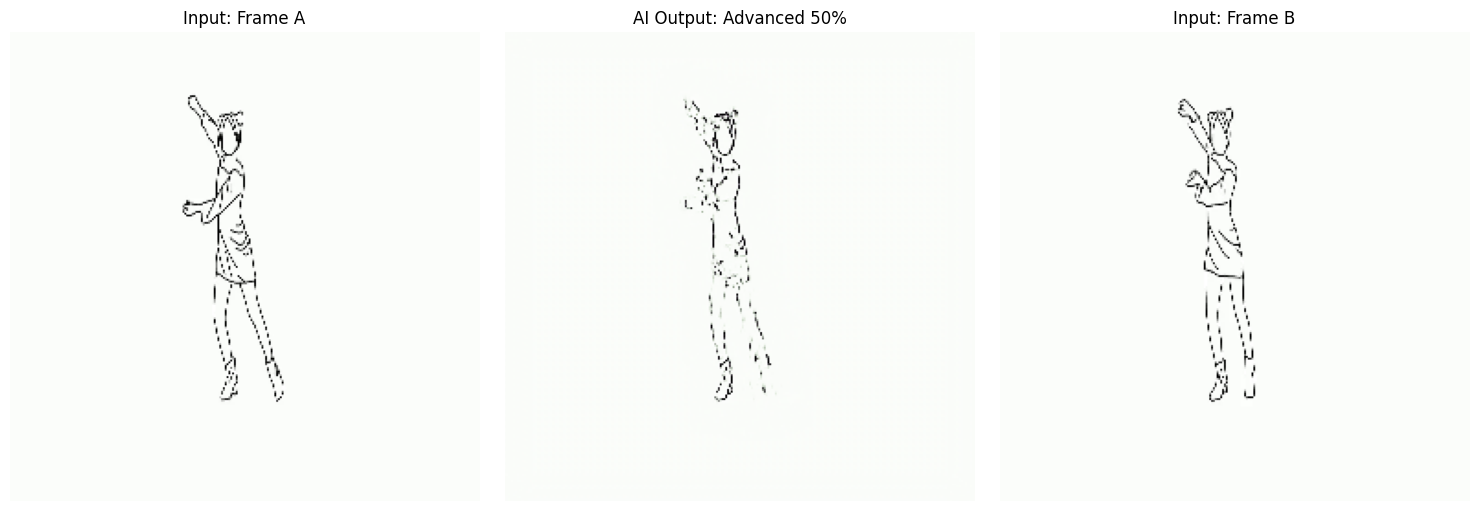

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

# --- CONFIGURATION ---
MODEL_PATH = "fusion_model.pth" 
IMG_SIZE = 256                  

# --- HARDWARE SETUP ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Generator hardware: {DEVICE}")

# --- 1. DEFINE THE ADVANCED MODEL ARCHITECTURE ---
# This MUST perfectly match the new Phase 5 skeleton
class AdvancedFusionNet(nn.Module):
    def __init__(self):
        super(AdvancedFusionNet, self).__init__()
        
        # Encoder
        self.enc1 = nn.Sequential(nn.Conv2d(6, 32, 3, 1, 1), nn.BatchNorm2d(32), nn.ReLU(inplace=True))
        self.enc2 = nn.Sequential(nn.Conv2d(32, 64, 3, 2, 1), nn.BatchNorm2d(64), nn.ReLU(inplace=True))
        self.enc3 = nn.Sequential(nn.Conv2d(64, 128, 3, 2, 1), nn.BatchNorm2d(128), nn.ReLU(inplace=True))
        
        # Bottleneck
        self.bottle = nn.Sequential(nn.Conv2d(128, 128, 3, 1, 1), nn.BatchNorm2d(128), nn.ReLU(inplace=True))
        
        # Decoder + Skip Connections
        self.up3 = nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1)
        self.dec3 = nn.Sequential(nn.Conv2d(128, 64, 3, 1, 1), nn.BatchNorm2d(64), nn.ReLU(inplace=True))
        
        self.up2 = nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1)
        self.dec2 = nn.Sequential(nn.Conv2d(64, 32, 3, 1, 1), nn.BatchNorm2d(32), nn.ReLU(inplace=True))
        
        self.final = nn.Conv2d(32, 3, kernel_size=3, padding=1)
        
    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        
        b = self.bottle(e3)
        
        d3 = self.up3(b)
        d3 = torch.cat([d3, e2], dim=1) # <-- SKIP CONNECTION
        d3 = self.dec3(d3)
        
        d2 = self.up2(d3)
        d2 = torch.cat([d2, e1], dim=1) # <-- SKIP CONNECTION
        d2 = self.dec2(d2)
        
        return torch.sigmoid(self.final(d2))

# --- 2. LOAD THE TRAINED MODEL ---
model = AdvancedFusionNet().to(DEVICE)
if os.path.exists(MODEL_PATH):
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    
    # CRITICAL FIX for Advanced Architecture: 
    # .eval() disables BatchNorm training updates to freeze the brain for inference
    model.eval() 
    print("✅ Advanced AI Brain Loaded Successfully!")
else:
    print(f"❌ Error: {MODEL_PATH} not found. Train the model first.")

# --- 3. UPGRADED WARPING LOGIC ---
def warp_tensor(img_tensor, flow_tensor):
    N, C, H, W = img_tensor.shape
    xx = torch.arange(0, W).view(1, -1).repeat(H, 1)
    yy = torch.arange(0, H).view(-1, 1).repeat(1, W)
    xx = xx.view(1, 1, H, W).repeat(N, 1, 1, 1)
    yy = yy.view(1, 1, H, W).repeat(N, 1, 1, 1)
    grid = torch.cat((xx, yy), 1).float()
    if img_tensor.device.type != 'cpu': 
        grid = grid.to(DEVICE)
    vgrid = grid + flow_tensor
    vgrid[:, 0, :, :] = 2.0 * vgrid[:, 0, :, :] / max(W - 1, 1) - 1.0
    vgrid[:, 1, :, :] = 2.0 * vgrid[:, 1, :, :] / max(H - 1, 1) - 1.0
    vgrid = vgrid.permute(0, 2, 3, 1)
    
    # Matching the Phase 5 border padding upgrade
    return F.grid_sample(img_tensor, vgrid, align_corners=True, padding_mode='border')

def generate_single_middle_frame(img1_s, img2_s):
    prev_gray = cv2.cvtColor(img1_s, cv2.COLOR_BGR2GRAY)
    next_gray = cv2.cvtColor(img2_s, cv2.COLOR_BGR2GRAY)
    
    flow = cv2.calcOpticalFlowFarneback(prev_gray, next_gray, None, 0.5, 5, 25, 10, 5, 1.2, 0)
    
    t1 = torch.from_numpy(img1_s).permute(2, 0, 1).float().unsqueeze(0) / 255.0
    t2 = torch.from_numpy(img2_s).permute(2, 0, 1).float().unsqueeze(0) / 255.0
    t_flow = torch.from_numpy(flow).permute(2, 0, 1).float().unsqueeze(0)
    
    t1, t2, t_flow = t1.to(DEVICE), t2.to(DEVICE), t_flow.to(DEVICE)
    
    with torch.no_grad():
        warped_1 = warp_tensor(t1, t_flow * 0.5)
        warped_2 = warp_tensor(t2, t_flow * -0.5)
        cnn_input = torch.cat([warped_1, warped_2], dim=1)
        output = model(cnn_input)
        
    out_img = output.squeeze(0).permute(1, 2, 0).cpu().numpy()
    out_img = (out_img * 255).astype(np.uint8)
    
    return out_img

# --- 4. INTERACTIVE SINGLE-FRAME EXECUTION ---
print("\n--- Advanced Single Frame Interpolation Test ---")

frame_A_path = input("Enter path to FIRST keyframe: ").strip()
frame_B_path = input("Enter path to SECOND keyframe: ").strip()
output_path = input("Enter the name to save (e.g., advanced_middle.png): ").strip()

# --- SAFETY CHECKS ---
if not output_path.lower().endswith(('.png', '.jpg', '.jpeg')):
    print("⚠️ Automatically adding '.png' to the filename.")
    output_path += '.png'

output_dir = os.path.dirname(output_path)
if output_dir != '' and not os.path.exists(output_dir):
    os.makedirs(output_dir, exist_ok=True)
# ---------------------

if os.path.exists(frame_A_path) and os.path.exists(frame_B_path):
    print(f"\n⏳ Generating single middle frame using Advanced U-Net...")
    
    imgA = cv2.resize(cv2.imread(frame_A_path), (IMG_SIZE, IMG_SIZE))
    imgB = cv2.resize(cv2.imread(frame_B_path), (IMG_SIZE, IMG_SIZE))
    
    middle_gen = generate_single_middle_frame(imgA, imgB)
    
    cv2.imwrite(output_path, middle_gen)
    print(f"✅ Success! Saved to: '{output_path}'")
    
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].imshow(cv2.cvtColor(imgA, cv2.COLOR_BGR2RGB))
    ax[0].set_title("Input: Frame A")
    ax[0].axis('off')
    
    ax[1].imshow(cv2.cvtColor(middle_gen, cv2.COLOR_BGR2RGB))
    ax[1].set_title("AI Output: Advanced 50%")
    ax[1].axis('off')
    
    ax[2].imshow(cv2.cvtColor(imgB, cv2.COLOR_BGR2RGB))
    ax[2].set_title("Input: Frame B")
    ax[2].axis('off')
    
    plt.tight_layout()
    plt.show()

else:
    print("\n❌ Error: Could not find one or both of your input files.")